In [1]:
#loading the necessary packages


import numpy as np # for linear data
import pandas as pd # data processing, csv files i/o



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input\optiver-rnn-just-imb-models\all_data.pkl
/kaggle/input\optiver-rnn-just-imb-models\rnn_all_data.pkl
/kaggle/input\optiver-rnn-just-imb-models\swish_model_seed_0.h5



  

wap = ( BidPrice∗AskSize + AskPrice∗BidSize) / (BidSize+AskSize)

target = ( (StockWAP[t+60] / StockWAP [t]) − (IndexWAP [t+60] IndexWAP [t]) )∗10000

- columns:
    1. date_id = days
    2. seconds_in_bucket = final ::: 10 minutes -> 600 seconds
    

In [2]:
path = r'C:\Users\cwang\Desktop\Kaggle_optiver\train.csv'

In [3]:
def calc_wap1(df):
    wap = (df['bid_price'] * df['ask_size'] + df['ask_price'] * df['bid_size']) / (df['bid_size'] + df['ask_size'])
    return wap

def calc_wap2(df):
    wap = (df['bid_price'] * df['bid_size'] + df['ask_price'] * df['ask_size']) / (df['bid_size'] + df['ask_size'])
    return wap

def log_return(series):
    return np.log(series).diff()

# Calculate the realized volatility
def realized_volatility(series):
    return np.sqrt(np.sum(series**2))

# Function to count unique elements of a series
def count_unique(series):
    return len(np.unique(series))

def book_preprocessor(file_path):
    df = pd.read_csv(file_path)
    df= df.fillna(0)
    # Calculate Wap
    df['wap2'] = calc_wap2(df)
    # Calculate log returns
    df['log_return1'] = df.groupby(['time_id'])['wap'].apply(log_return)
    df['log_return2'] = df.groupby(['time_id'])['wap2'].apply(log_return)
    # Calculate wap balance
    df['wap_balance'] = abs(df['wap'] - df['wap2'])
    # Calculate spread
    df['price_spread'] = (df['ask_price'] - df['bid_price']) / ((df['ask_price'] + df['bid_price']) / 2)
    df['total_volume'] = df['ask_size'] + df['bid_size']
    return df



# # Dict for aggregations
# create_feature_dict = {
#     'wap1': [np.sum, np.std],
#     'wap2': [np.sum, np.std],
#     'log_return1': [realized_volatility],
#     'log_return2': [realized_volatility],
#     'wap_balance': [np.sum, np.max],
#     'price_spread':[np.sum, np.max],
#     'total_volume':[np.sum, np.max],
#     "bid_ask_spread":[np.sum,  np.max],
# }
# create_feature_dict_time = {
#     'log_return1': [realized_volatility],
#     'log_return2': [realized_volatility],
# }


df = book_preprocessor(path)

# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler(feature_range=(-1, 1))


c:\Users\cwang\anaconda3\envs\ml4t\lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\cwang\AppData\Local\Temp\ipykernel_13100\723801126.py:26: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df['log_return1'] = df.groupby(['time_id'])['wap'].apply(log_return)
c:\Users\cwang\anaconda3\envs\ml4t\lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\cwang\AppData\Local\Temp\ipykernel_13100\723801126.py:27: FutureWarning: Not prependi

In [4]:
df

,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,...,wap,target,time_id,row_id,wap2,log_return1,log_return2,wap_balance,price_spread,total_volume
0,0,0,0,3180602.69,1,0.999812,13380276.64,0.000000,0.000000,0.999812,...,1.000000,-3.029704,0,0_0_0,0.999838,NaN,NaN,0.000162,0.000214,69144.53
1,1,0,0,166603.91,-1,0.999896,1642214.25,0.000000,0.000000,0.999896,...,1.000000,-5.519986,0,0_0_1,1.000556,0.000000,0.000718,0.000556,0.000764,23838.13
2,2,0,0,302879.87,-1,0.999561,1819368.03,0.000000,0.000000,0.999403,...,1.000000,-8.389950,0,0_0_2,0.999702,0.000000,-0.000855,0.000298,0.000895,56951.00
3,3,0,0,11917682.27,-1,1.000171,18389745.62,0.000000,0.000000,0.999999,...,1.000000,-4.010200,0,0_0_3,1.000213,0.000000,0.000511,0.000213,0.000215,481357.30
4,4,0,0,447549.96,-1,0.999532,17860614.95,0.000000,0.000000,0.999394,...,1.000000,-7.349849,0,0_0_4,0.999410,0.000000,-0.000803,0.000590,0.000622,16919.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5237975,195,480,540,2440722.89,-1,1.000317,28280361.74,0.999734,0.999734,1.000317,...,1.000328,2.310276,26454,480_540_195,1.000423,-0.001228,-0.001438,0.000095,0.000117,352119.44
5237976,196,480,540,349510.47,-1,1.000643,9187699.11,1.000129,1.000386,1.000643,...,1.000819,-8.220077,26454,480_540_196,1.000723,0.000491,0.000300,0.000096,0.000257,298501.47
5237977,197,480,540,0.00,0,0.995789,12725436.10,0.995789,0.995789,0.995789,...,0.995797,1.169443,26454,480_540_197,0.995875,-0.005031,-0.004857,0.000078,0.000094,196828.98
5237978,198,480,540,1000898.84,1,0.999210,94773271.05,0.999210,0.999210,0.998970,...,0.999008,-1.540184,26454,480_540_198,0.999172,0.003219,0.003305,0.000164,0.000240,795524.72


# 1.Data Analysis

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go

ModuleNotFoundError: No module named 'plotly'

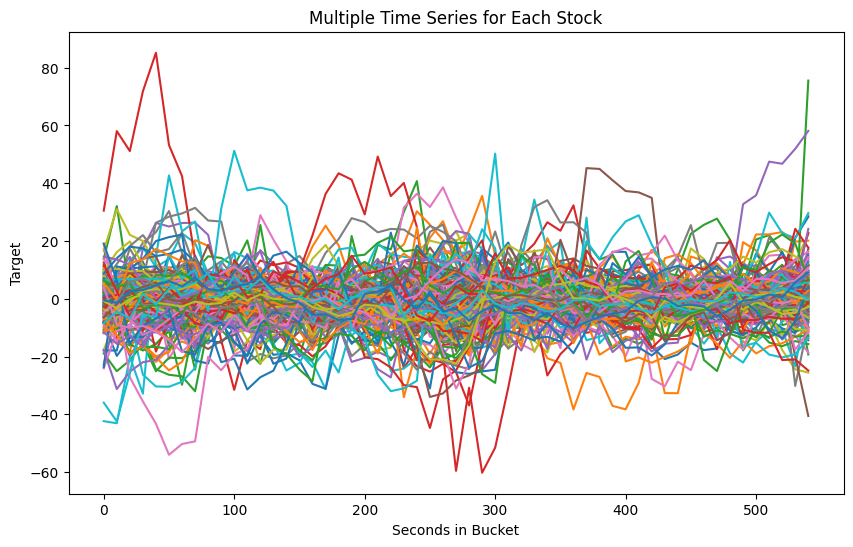

In [ ]:
# Ploting time series for target in day 0 

df_plt = (
    df
    .query('date_id == 0')
    [['stock_id', 'target', 'seconds_in_bucket']]
)

plt.figure(figsize=(10, 6))

for stock in df_plt['stock_id'].unique():
    df_stock = df_plt[df_plt['stock_id'] == stock]
    plt.plot(df_stock['seconds_in_bucket'], df_stock['target'], label=f'Stock {stock}')

plt.xlabel('Seconds in Bucket')
plt.ylabel('Target')
plt.title('Multiple Time Series for Each Stock')
plt.show()

<Axes: title={'center': 'Bid and Ask over the stock and day 0'}, xlabel='seconds_in_bucket'>

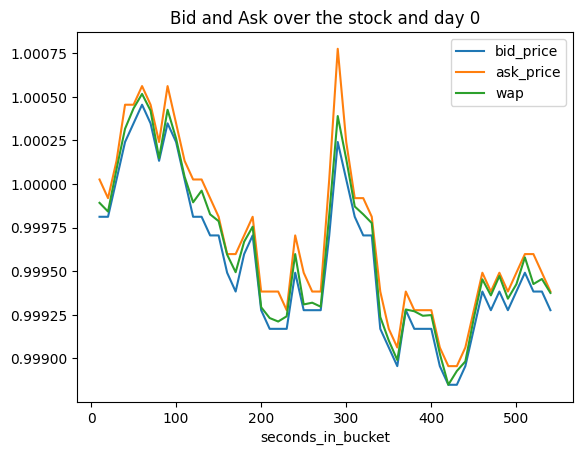

In [ ]:
# Ploting the bid and ask price to stock and day 0

(
    df
    .query('stock_id == 0 & date_id == 0')
    [['seconds_in_bucket','bid_price','ask_price', 'wap']]
    .replace(0, np.nan)
    .set_index('seconds_in_bucket')
    .plot(title = 'Bid and Ask over the stock and day 0')
)

<Axes: title={'center': 'Stock 0 on Day 0 - Ploting the near, far and reference prices'}, xlabel='seconds_in_bucket'>

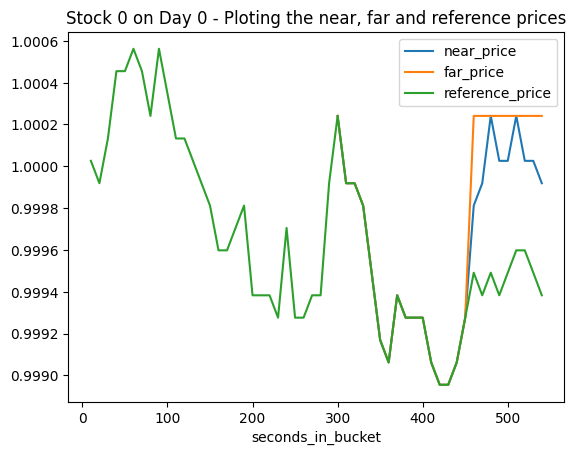

In [ ]:
# Ploting the near, far and reference prices

(
    df
    .query('stock_id ==0 & date_id ==0')
    [['seconds_in_bucket','near_price','far_price','reference_price']]
    .replace(0, np.nan)
    .set_index('seconds_in_bucket')
    .plot(title = 'Stock 0 on Day 0 - Ploting the near, far and reference prices')
)

<Axes: title={'center': 'Stock 0 on Day 0 - Imbalance and matched'}, xlabel='seconds_in_bucket'>

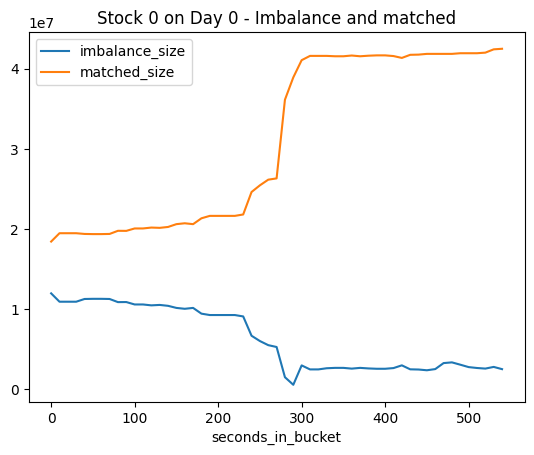

In [ ]:
# Imbalance and matched size plotting

(
    df
    .query('stock_id == 3 & date_id ==0')
    [['seconds_in_bucket','imbalance_size','matched_size']]
    .set_index('seconds_in_bucket')
    .plot(title='Stock 0 on Day 0 - Imbalance and matched')
)

# Feature engineering

In [ ]:
def feature_cols(df):
    columns = [col for col in df.columns if col not in ['row_id', 'time_id', 'date_id', 'stock_id', 'currently_scored']]
    return df[columns]

In [ ]:
df.fillna(0, inplace=True)

In [ ]:
x_train = feature_cols(df.drop(columns='target'))
x_train.fillna(0, inplace = True)

In [ ]:
y_train = df['target'].values

# Splitting the data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, x_test, Y_train, y_test = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Modelling

In [ ]:
# Created the modeling with lgbm regressors 

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

import lightgbm as lgb
from lightgbm import LGBMRegressor

pd.set_option("display.max_columns", None)

In [ ]:
from sklearn.pipeline import Pipeline, FunctionTransformer

model = lgb.LGBMRegressor(objective='mae', n_estimators=200, random_state=55)

pipe = Pipeline([
    ('select_features', FunctionTransformer(feature_cols, validate=False)),
    ('model', model)
])

In [ ]:
pipe.fit(X_train, Y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.121839 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3628
[LightGBM] [Info] Number of data points in the train set: 4190384, number of used features: 16
[LightGBM] [Info] Start training from score -0.060201


Pipeline(steps=[('select_features',
                 FunctionTransformer(func=<function feature_cols at 0x000001E9AAA79C60>)),
                ('model',
                 LGBMRegressor(n_estimators=200, objective='mae',
                               random_state=55))])

In [ ]:
## Validating the model

y_pred = pipe.predict(x_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print(mae)

6.279339541082625
